# Análisis exploratorio de datos - Espectro de respuesta (Ing. Sísmica)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv(r'C:\Users\elias\OneDrive\Desktop\dataviz_py\eda-jbook\docs\NGACOL.csv')

In [3]:
df

,Hypocenter Depth (km),Magnitude,Rrup_OpenQuake,Soil_Class,Tmax,origen,Seismic Latitude,Seismic Longitude,Station Latitude,Station Longitude,T_0.01_RotD50
0,7.213,3.4,2.503074,2,0.808081,NGAW2,37.1173,-121.5231,37.1635,-121.6265,-6.819442
1,7.213,3.4,3.296947,3,1.081081,NGAW2,37.1173,-121.5231,37.0492,-121.8072,-6.369086
2,7.213,3.4,3.551053,3,1.081081,NGAW2,37.1173,-121.5231,36.9275,-121.8276,-5.961014
3,7.213,3.4,2.999226,3,1.333333,NGAW2,37.1173,-121.5231,37.1543,-121.7347,-5.323799
4,8.469,3.4,2.526528,3,1.666667,NGAW2,36.6008,-121.2089,36.6181,-121.3147,-2.696168
...,...,...,...,...,...,...,...,...,...,...,...
10234,10.040,7.9,6.091197,3,20.000000,NGAW2,30.9860,103.3640,36.4000,103.8000,-4.435628
10235,10.040,7.9,5.892141,3,26.666667,NGAW2,30.9860,103.3640,35.8000,104.1000,-4.283697
10236,10.040,7.9,5.929802,2,26.666667,NGAW2,30.9860,103.3640,35.8000,103.9000,-4.434821
10237,10.040,7.9,6.031838,3,13.333333,NGAW2,30.9860,103.3640,36.0000,103.3000,-4.438374


## Glosario de términos


| Variable | Tipo | Unidad / Formato | Rol (GMPE) | Descripción clara | Chequeos / validaciones rápidas |
|---|---|---|---|---|---|
| Hypocenter Depth (km) | Numérica (float) | km | Fuente | Profundidad del hipocentro del sismo. | ≥ 0; revisar outliers; comparar por `origen`.|
| Magnitude | Numérica (float) | Magnitud Mw | Fuente | Magnitud del evento sísmico. | Rango típico ~[0, 9]; detectar nulos|
| Rrup_OpenQuake | Numérica (float) | km | Trayectoria | Distancia **Rrup** (fuente–sitio), calculada con OpenQuake (por el nombre). | > 0; revisar ceros; distribución sesgada|
| Soil_Class | Categórica (string/int) | Clase 1,2,3,4,5 | Sitio | Clasificación de suelo/condición de sitio de la estación. | Revisar categorías únicas; estandarizar etiquetas|
| Tmax | Numérica (float) | segundos | Feature | periodo máximo válido del espectro | documentar cómo se calcula. |
| origen | Categórica (string) | Etiqueta (NGAW2 o Colombia) | Metadato | de que dataset viene| Revisar categorías; analizar sesgos por origen (M, Depth, Rrup). |
| Seismic Latitude | Numérica (float) | grados | Geo (evento) | Latitud del evento (epicentro/ubicación del sismo). | En [-90, 90]|
| Seismic Longitude | Numérica (float) | grados | Geo (evento) | Longitud del evento. | En [-180, 180]|
| Station Latitude | Numérica (float) | grados | Geo (estación) | Latitud de la estación sísmica (sitio). | En [-90, 90]|
| Station Longitude | Numérica (float) | grados | Geo (estación) | Longitud de la estación sísmica (sitio). | En [-180, 180]|
| T_0.01_RotD50 | Numérica (float) | g (si es Sa) o unidades del registro | Respuesta | Medida de movimiento del suelo **RotD50** en **T = 0.01 s** (típicamente Sa(T) RotD50). | > 0; analizar en log; revisar valores cercanos a 0; outliers muy altos. |

La variable de respuesta es T_0.01_RotD50 que indica el logaritmo de la aceleración del suelo a en un punto a partir de un evento sísmico específico

In [4]:
inputs = df.drop('T_0.01_RotD50', axis=1)
output = df['T_0.01_RotD50']

In [5]:
print(df.columns)

Index(['Hypocenter Depth (km)', 'Magnitude', 'Rrup_OpenQuake', 'Soil_Class',
       'Tmax', 'origen', 'Seismic Latitude', 'Seismic Longitude',
       'Station Latitude', 'Station Longitude', 'T_0.01_RotD50'],
      dtype='object')


In [6]:
print(df.isna().sum())

Hypocenter Depth (km)     0
Magnitude                 0
Rrup_OpenQuake            0
Soil_Class                0
Tmax                     35
origen                    0
Seismic Latitude          0
Seismic Longitude         0
Station Latitude          0
Station Longitude         0
T_0.01_RotD50             0
dtype: int64


## Análisis univariado

### T_0.01_RotD50

La variable será tratada con la transformación exponencial que representa la aceleración real. (El logaritmo es la transformación que se le realiza cuando se quiere aplicar modelos de machine learning, ya que esta transformación mejora la distribución)

In [7]:
col = "T_0.01_RotD50"
s = pd.to_numeric(np.exp(df[col]), errors="coerce")

print("=== Resumen:", col, "===")
print("n_valid:", int(s.notna().sum()))
print("n_missing:", int(s.isna().sum()))
print("min:", float(s.min()) if s.notna().any() else np.nan)
print("median:", float(s.median()) if s.notna().any() else np.nan)
print("max:", float(s.max()) if s.notna().any() else np.nan)


=== Resumen: T_0.01_RotD50 ===
n_valid: 10239
n_missing: 0
min: 0.00011283500000000001
median: 0.016961839999999995
max: 1.793158


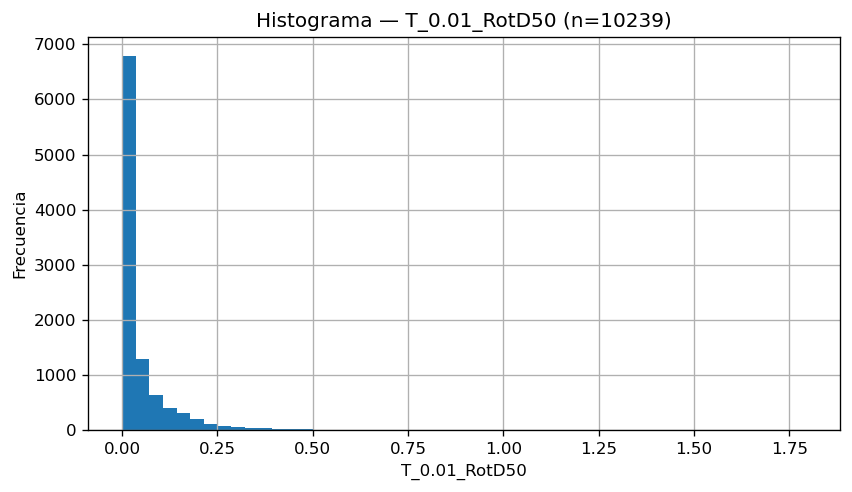

In [8]:
x = s.dropna()

plt.figure(figsize=(7.2, 4.2), dpi=120)
plt.hist(x, bins=50)
plt.title(f"Histograma — {col} (n={len(x)})")
plt.xlabel(col); plt.ylabel("Frecuencia")
plt.grid(True); plt.tight_layout()
plt.show()

Se puede evidenciar como los valores están muy sesgados con cola hacia la derecha de manera que la mayor cantidad de datos se encuentra en valores muy bajos. 

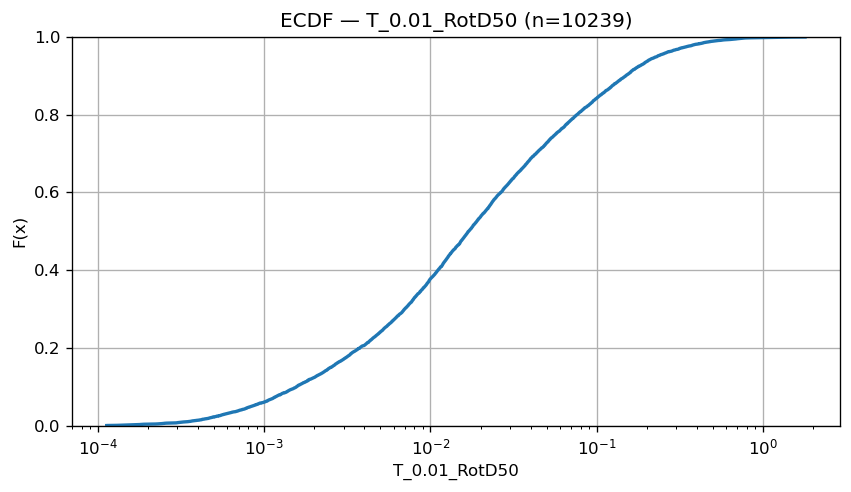

In [9]:
x_sorted = np.sort(x.values)
y = np.arange(1, len(x_sorted) + 1) / len(x_sorted) if len(x_sorted) else np.array([])

plt.figure(figsize=(7.2, 4.2), dpi=120)
plt.plot(x_sorted, y, linewidth=2)
plt.title(f"ECDF — {col} (n={len(x_sorted)})")
plt.xlabel(col); plt.ylabel("F(x)")
plt.ylim(0, 1)
plt.xscale("log")
plt.grid(True); plt.tight_layout()
plt.show()

La variable cubre varios órdenes de magnitud. La mediana se encuentra alrededor de 2x10-2.
Se observa cola derecha (pocos casos con valores altos), porque la ECDF se “aplana” acercándose a 1 para valores grandes.

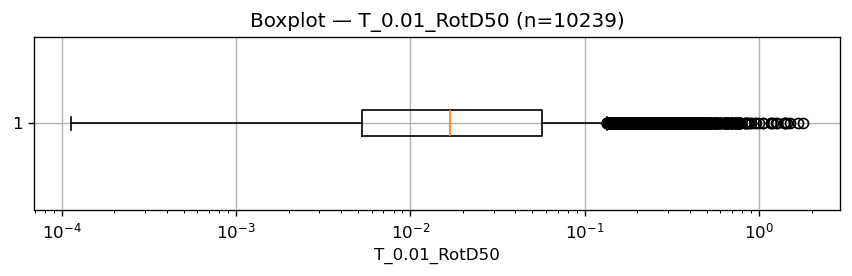

In [10]:
plt.figure(figsize=(7.2, 2.4), dpi=120)
plt.boxplot(x.values, vert=False, showfliers=True)
plt.title(f"Boxplot — {col} (n={len(x)})")
plt.xlabel(col)
plt.xscale("log")
plt.grid(True); plt.tight_layout()
plt.show()

Se puede evidenciar una gran cantidad de datos atípicos a la derecha por encima de 0.1, con una mediana entre 0.01 y 0.02 que sugiere que mas del 50% de los datos se encuentran por debajo de 0.02 g (unidades de gravedad)

In [11]:
# Resumen de medidas de tendencia y dispersión para la variable objetivo
s = pd.to_numeric(df['T_0.01_RotD50'], errors='coerce').dropna()

print("Describe:")
print(s.describe(), "\n")

print("Moda (puede tener múltiples valores):")
print(s.mode().values, "\n")

print(f"Asimetría (skew): {s.skew():.6f}")
print(f"Curtosis (kurtosis): {s.kurt():.6f}")

Describe:
count    10239.000000
mean        -4.115497
std          1.698535
min         -9.089584
25%         -5.246313
50%         -4.076789
75%         -2.871488
max          0.583978
Name: T_0.01_RotD50, dtype: float64 

Moda (puede tener múltiples valores):
[-5.19084498 -4.92874116 -4.74719918 -4.14897077 -4.09840921] 

Asimetría (skew): -0.172572
Curtosis (kurtosis): -0.427023


Con un mínimo entre 10-4 y 10-3 al expandir el eje horizontal, se puede evidenciar que la distribución está balanceada a derecha y la izquierda

### Magnitud (escala de magnitud de momentos)

In [12]:
col = "Magnitude"
s = pd.to_numeric(df[col], errors="coerce")

print("=== Resumen:", col, "===")
print("n_valid:", int(s.notna().sum()))
print("n_missing:", int(s.isna().sum()))
print("min:", float(s.min()) if s.notna().any() else np.nan)
print("median:", float(s.median()) if s.notna().any() else np.nan)
print("max:", float(s.max()) if s.notna().any() else np.nan)

=== Resumen: Magnitude ===
n_valid: 10239
n_missing: 0
min: 3.2
median: 6.2
max: 7.9


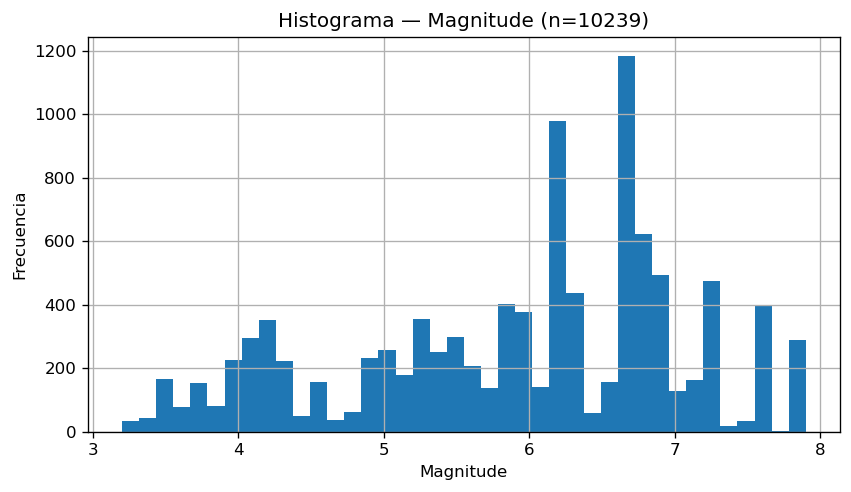

In [13]:
x = s.dropna()

plt.figure(figsize=(7.2, 4.2), dpi=120)
plt.hist(x, bins=40)
plt.title(f"Histograma — {col} (n={len(x)})")
plt.xlabel(col); plt.ylabel("Frecuencia")
plt.grid(True); plt.tight_layout()
plt.show()


Rango aproximado 3.2 a 8.0. La distribución posee varios picos lo que muestra mezcla de lugares. La mayor densidad está entre 5.0 y 7.0, con eventos grandes presentes pero menos frecuentes hacia >7.5.

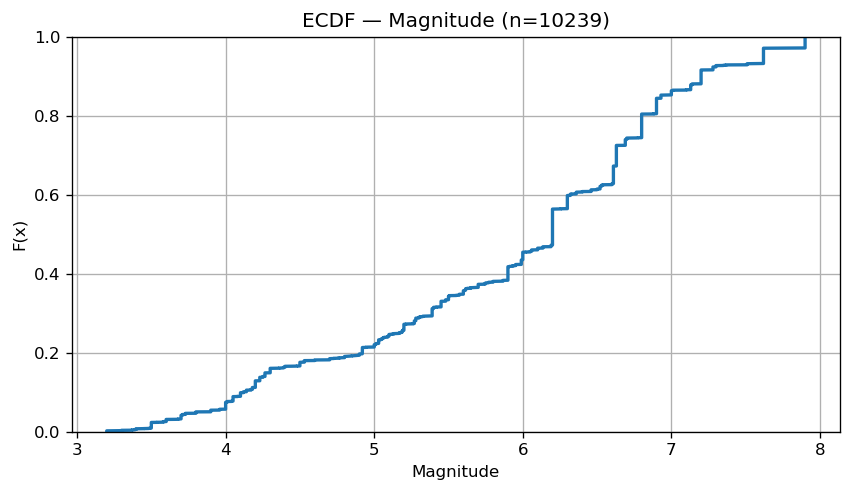

In [14]:
x_sorted = np.sort(x.values)
y = np.arange(1, len(x_sorted) + 1) / len(x_sorted) if len(x_sorted) else np.array([])

plt.figure(figsize=(7.2, 4.2), dpi=120)
plt.plot(x_sorted, y, linewidth=2)
plt.title(f"ECDF — {col} (n={len(x_sorted)})")
plt.xlabel(col); plt.ylabel("F(x)")
plt.ylim(0, 1)
plt.grid(True); plt.tight_layout()
plt.show()

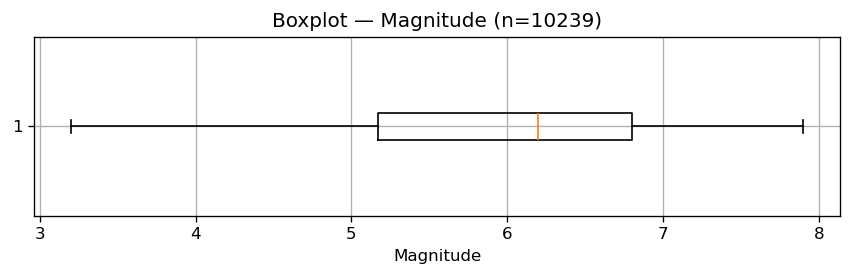

In [15]:
plt.figure(figsize=(7.2, 2.4), dpi=120)
plt.boxplot(x.values, vert=False, showfliers=True)
plt.title(f"Boxplot — {col} (n={len(x)})")
plt.xlabel(col)
plt.grid(True); plt.tight_layout()
plt.show()

El boxplot indica que no hay valores atipicos. Mas del 75% de los datos se encuentran por debajo de magnitudes de 7 lo que indica que el 25% restante son sismos de gran magnitud.

### Hypocenter Depth (km). Profundidad hipocentral

In [16]:
col = "Hypocenter Depth (km)"
s = pd.to_numeric(df[col], errors="coerce")

print("=== Resumen:", col, "===")
print("n_valid:", int(s.notna().sum()))
print("n_missing:", int(s.isna().sum()))
print("min:", float(s.min()) if s.notna().any() else np.nan)
print("median:", float(s.median()) if s.notna().any() else np.nan)
print("max:", float(s.max()) if s.notna().any() else np.nan)


=== Resumen: Hypocenter Depth (km) ===
n_valid: 10239
n_missing: 0
min: 1.331
median: 10.0
max: 58.7


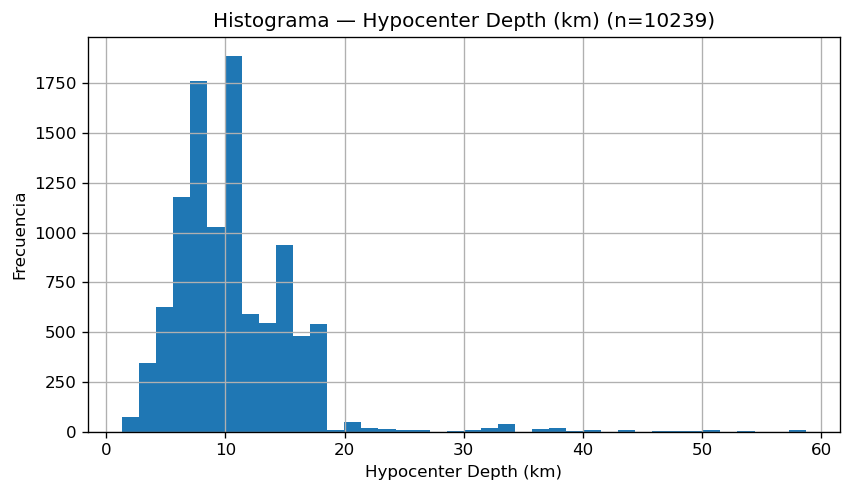

In [17]:
x = s.dropna()

plt.figure(figsize=(7.2, 4.2), dpi=120)
plt.hist(x, bins=40)
plt.title(f"Histograma — {col} (n={len(x)})")
plt.xlabel(col); plt.ylabel("Frecuencia")
plt.grid(True); plt.tight_layout()
plt.show()

La mayoría de eventos son someros es decir, existe concentración fuerte entre 5 y 15 km. Hay una cola de pocos eventos más profundos hasta 60km.

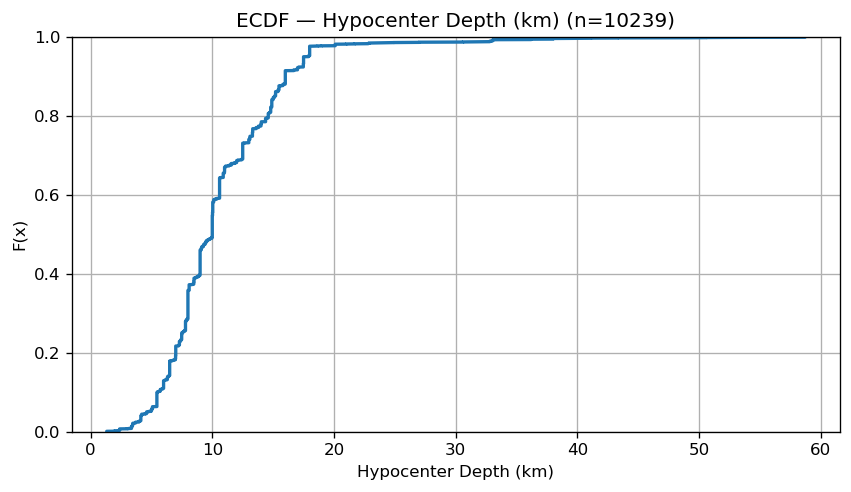

In [18]:
x_sorted = np.sort(x.values)
y = np.arange(1, len(x_sorted) + 1) / len(x_sorted) if len(x_sorted) else np.array([])

plt.figure(figsize=(7.2, 4.2), dpi=120)
plt.plot(x_sorted, y, linewidth=2)
plt.title(f"ECDF — {col} (n={len(x_sorted)})")
plt.xlabel(col); plt.ylabel("F(x)")
plt.ylim(0, 1)
plt.grid(True); plt.tight_layout()
plt.show()

La profundidad crece rápido en la ECDF antes de 20 km: por lectura visual, alrededor del 95% de los registros están por debajo de 18–20 km lo que confirma que el dataset está conformado por sismos corticales (superficiales)

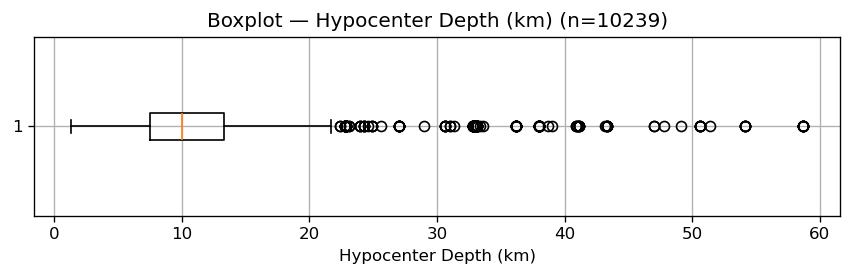

In [19]:
plt.figure(figsize=(7.2, 2.4), dpi=120)
plt.boxplot(x.values, vert=False, showfliers=True)
plt.title(f"Boxplot — {col} (n={len(x)})")
plt.xlabel(col)
plt.grid(True); plt.tight_layout()
plt.show()

Se puede evidenciar una gran cantidad de outliers y muy separados entre si. Sugiere que un poco mas del 75% de los datos se encuentran por debajo de 20km de profundidad.

### Rrup_OpenQuake (Distancia de ruptura)

In [20]:
col = "Rrup_OpenQuake"
s = pd.to_numeric(np.exp(df[col]), errors="coerce")

print(" Resumen:", col,)
print("n_valid:", int(s.notna().sum()))
print("n_missing:", int(s.isna().sum()))
print("min:", float(s.min()) if s.notna().any() else np.nan)
print("median:", float(s.median()) if s.notna().any() else np.nan)
print("max:", float(s.max()) if s.notna().any() else np.nan)

 Resumen: Rrup_OpenQuake
n_valid: 10239
n_missing: 0
min: 0.05000000000000001
median: 71.48000000000008
max: 1532.66


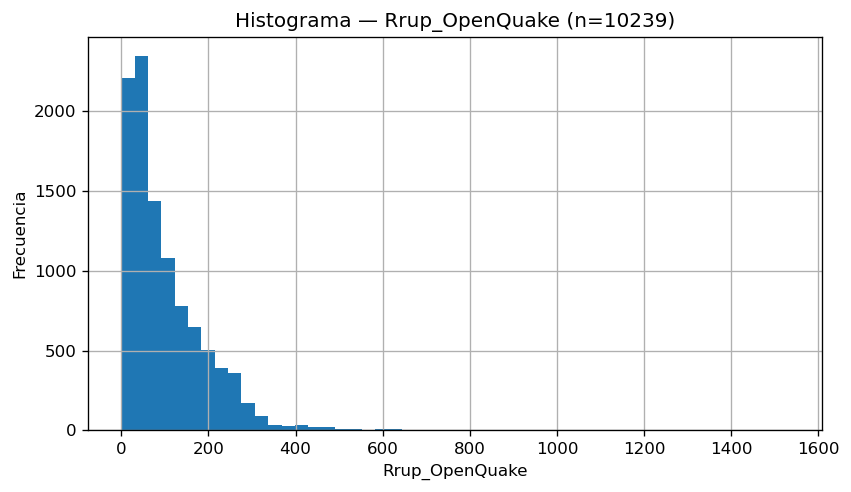

In [21]:
x = s.dropna()

plt.figure(figsize=(7.2, 4.2), dpi=120)
plt.hist(x, bins=50)
plt.title(f"Histograma — {col} (n={len(x)})")
plt.xlabel(col); plt.ylabel("Frecuencia")
plt.grid(True); plt.tight_layout()
plt.show()

Distribución fuertemente sesgada a la derecha: muchos registros a distancias pequeñas/medias y pocos a distancias grandes
Hay una cola larga con valores que llegan hasta 1600 km (es por ello que siempre se usa la transformación logarítmica también para esta variable)

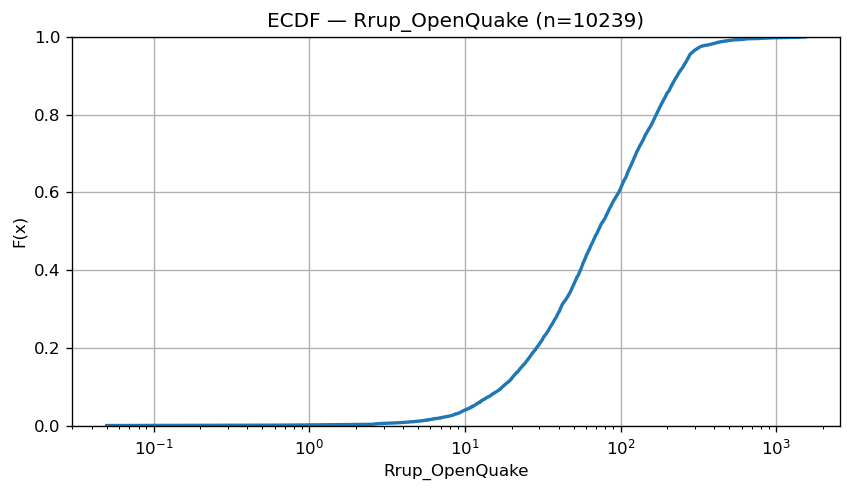

In [22]:
x_sorted = np.sort(x.values)
y = np.arange(1, len(x_sorted) + 1) / len(x_sorted) if len(x_sorted) else np.array([])

plt.figure(figsize=(7.2, 4.2), dpi=120)
plt.plot(x_sorted, y, linewidth=2)
plt.title(f"ECDF — {col} (n={len(x_sorted)})")
plt.xlabel(col); plt.ylabel("F(x)")
plt.xscale("log")
plt.ylim(0, 1)
plt.grid(True); plt.tight_layout()
plt.show()

La ECDF sugiere que la mayor parte de registros está entre 10 y 200 km. Visualmente, la mediana está alrededor de 70–80 km. Aproximadamente, la mayor parte del crecimiento ocurre antes de 300–400 km.
Notar que se usó la escala logarítmica en el eje horizontal.

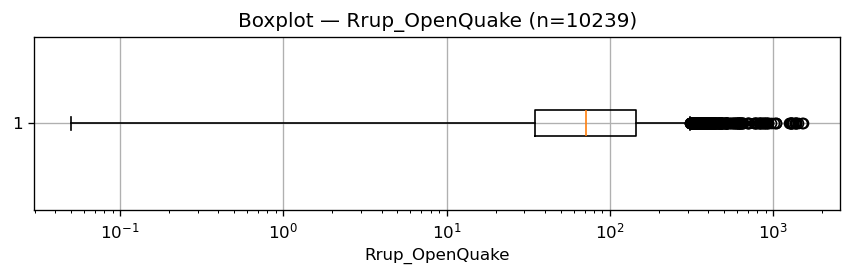

In [23]:
plt.figure(figsize=(7.2, 2.4), dpi=120)
plt.boxplot(x.values, vert=False, showfliers=True)
plt.title(f"Boxplot — {col} (n={len(x)})")
plt.xlabel(col)
plt.xscale("log")
plt.grid(True); plt.tight_layout()
plt.show()

Aún teniendo la mediana por valores cercanos a 100, hay una gran cantidad de datos atipicos a la derecha con distancias de ruptura entre 300km y 2000km.
El 50% de los datos está por debajo de los 70km de distancia de ruptura

### Tmax (Periodo máximo confiable para la señal recibida)

In [24]:
col = "Tmax"
s = pd.to_numeric(df[col], errors="coerce")

In [25]:
print("Resumen:", col)
print("n_valid:", int(s.notna().sum()))
print("n_missing:", int(s.isna().sum()))
print("min:", float(s.min()) if s.notna().any() else np.nan)
print("median:", float(s.median()) if s.notna().any() else np.nan)
print("max:", float(s.max()) if s.notna().any() else np.nan)


Resumen: Tmax
n_valid: 10204
n_missing: 35
min: 0.0949492686057839
median: 8.88888888888889
max: 133.33333333333334


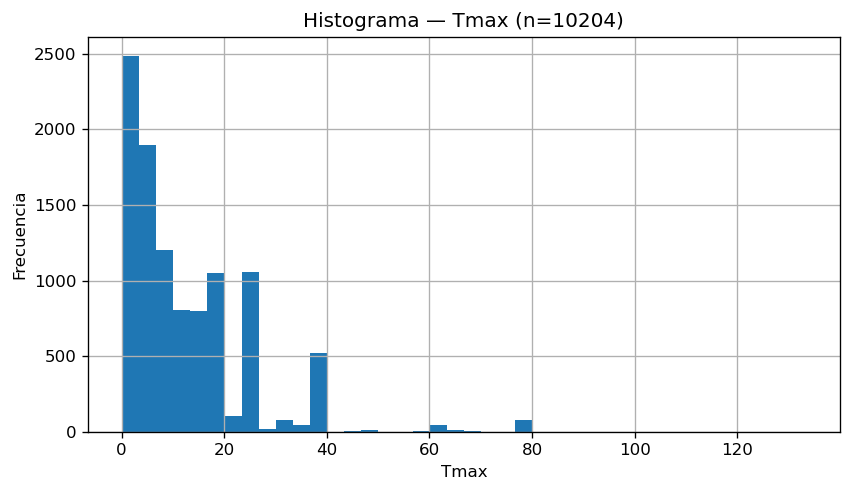

In [26]:
x = s.dropna()

plt.figure(figsize=(7.2, 4.2), dpi=120)
plt.hist(x, bins=40)
plt.title(f"Histograma — {col} (n={len(x)})")
plt.xlabel(col); plt.ylabel("Frecuencia")
plt.grid(True); plt.tight_layout()
plt.show()


Concentración muy fuerte en valores bajos (cerca de 0–10). Hay valores muy alejados del grupo inicial

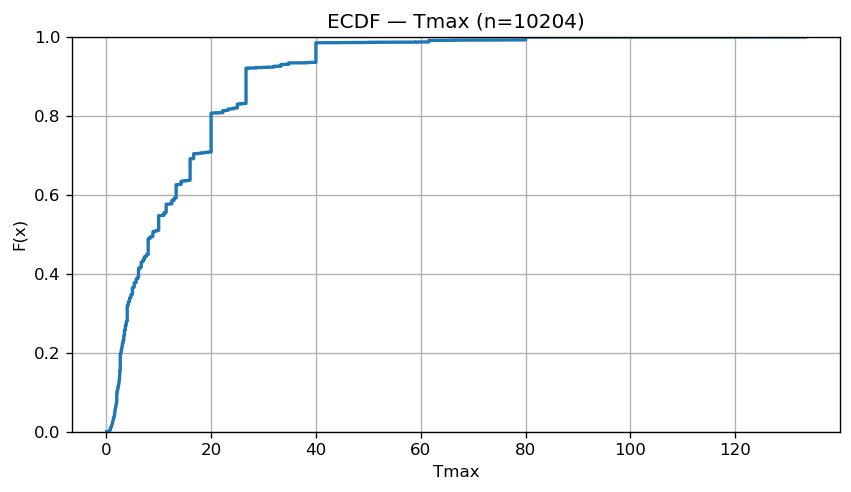

In [27]:
x_sorted = np.sort(x.values)
y = np.arange(1, len(x_sorted) + 1) / len(x_sorted) if len(x_sorted) else np.array([])

plt.figure(figsize=(7.2, 4.2), dpi=120)
plt.plot(x_sorted, y, linewidth=2)
plt.title(f"ECDF — {col} (n={len(x_sorted)})")
plt.xlabel(col); plt.ylabel("F(x)")
plt.ylim(0, 1)
plt.grid(True); plt.tight_layout()
plt.show()

La acumulación es muy rápida, 80% está por debajo de 20 y 95% por debajo de 40 aproximadamente.Hay una cola pequeña que llega a 130.

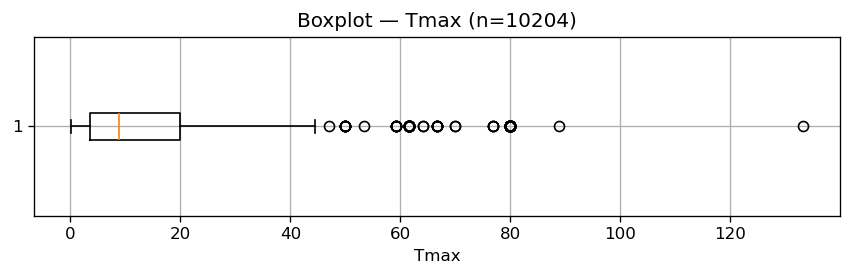

In [28]:
plt.figure(figsize=(7.2, 2.4), dpi=120)
plt.boxplot(x.values, vert=False, showfliers=True)
plt.title(f"Boxplot — {col} (n={len(x)})")
plt.xlabel(col)
plt.grid(True); plt.tight_layout()
plt.show()

### Soil_Class 

In [29]:
col = "Soil_Class"
s = df[col].astype("string")

counts = s.value_counts(dropna=False)
perc = 100 * counts / counts.sum()

In [30]:
print("Resumen:", col)
print("n_total:", len(df))
print("categorías:", int(counts.shape[0]))
print("\nTop categorías:\n", counts.head(10))


Resumen: Soil_Class
n_total: 10239
categorías: 5

Top categorías:
 Soil_Class
3    6053
4    2066
2    1571
5     439
1     110
Name: count, dtype: Int64


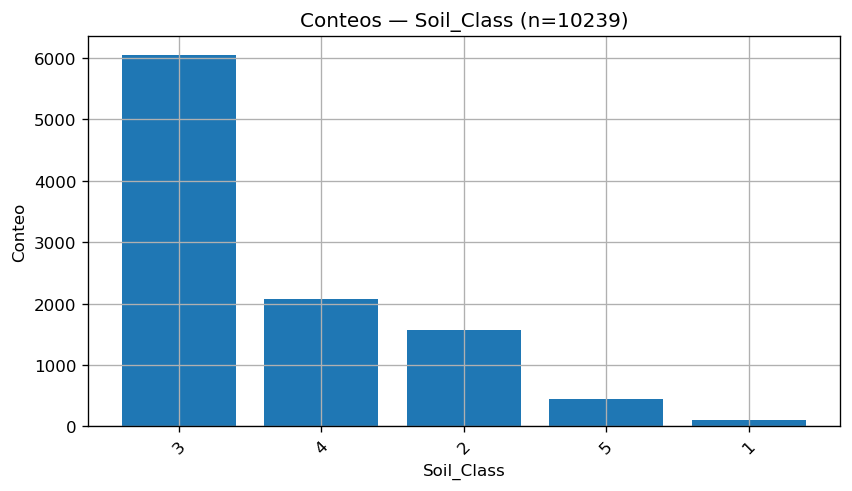

In [31]:
# Conteos
plt.figure(figsize=(7.2, 4.2), dpi=120)
plt.bar(counts.index.astype(str), counts.values)
plt.title(f"Conteos — {col} (n={len(df)})")
plt.xlabel(col); plt.ylabel("Conteo")
plt.xticks(rotation=45)
plt.grid(True); plt.tight_layout()
plt.show()


Dataset muy desbalanceado: Soil_Class = 3 domina claramente. Clases 4 y 2 aportan un bloque importante, mientras 5 es minoritaria y 1 es casi residual. Esto implicará que cualquier análisis puede quedar sesgado hacia la clase 3 si no controlas por balance/ponderación/estratificación.

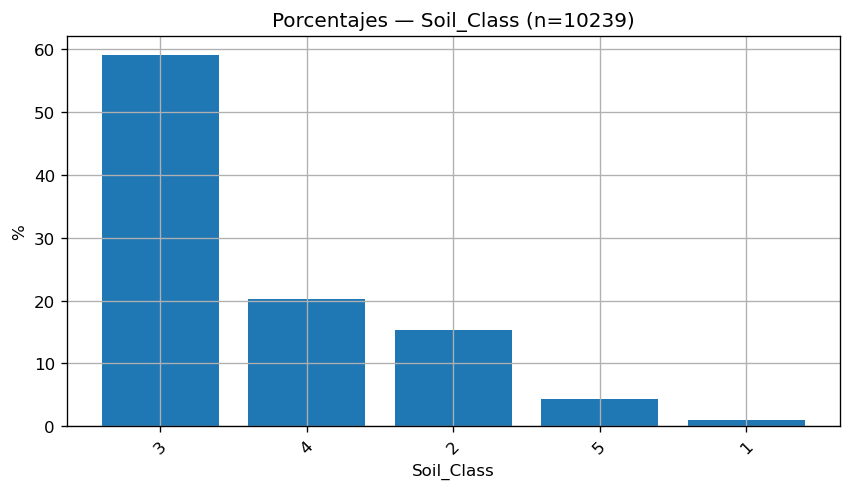

In [32]:
# Porcentajes
plt.figure(figsize=(7.2, 4.2), dpi=120)
plt.bar(perc.index.astype(str), perc.values)
plt.title(f"Porcentajes — {col} (n={len(df)})")
plt.xlabel(col); plt.ylabel("%")
plt.xticks(rotation=45)
plt.grid(True); plt.tight_layout()
plt.show()

### Estaciones sísmicas usadas

In [33]:
import geopandas as gpd
import plotly.express as px

In [34]:
d = df[["Station Latitude", "Station Longitude"]].copy()
d["Station Latitude"] = pd.to_numeric(d["Station Latitude"], errors="coerce")
d["Station Longitude"] = pd.to_numeric(d["Station Longitude"], errors="coerce")
d = d.dropna()

fig = px.scatter_geo(
    d,
    lat="Station Latitude",
    lon="Station Longitude",
    projection="natural earth",
    title=f"Estaciones — Mapa global (n={len(d)})",
)

fig.update_traces(marker=dict(size=4, opacity=0.5))
fig.update_layout(height=520)
fig.show()

In [35]:
lat_col = "Station Latitude"
lon_col = "Station Longitude"

d = df[[lat_col, lon_col]].copy()
d[lat_col] = pd.to_numeric(d[lat_col], errors="coerce")
d[lon_col] = pd.to_numeric(d[lon_col], errors="coerce")
d = d.dropna()

# Conteo exacto 
unique_exact = d.drop_duplicates().shape[0]

# Conteo con redondeo (para evitar micro-variaciones)
decimals = 4 
dr = d.round(decimals)
unique_rounded = dr.drop_duplicates().shape[0]

In [36]:
print("=== Estaciones (pares lat/lon) ===")
print("Registros con lat/lon válidos:", len(d))
print("Estaciones únicas (exacto):", unique_exact)
print(f"Estaciones únicas (redondeo a {decimals} decimales):", unique_rounded)

counts = (
    dr.groupby([lat_col, lon_col])
      .size()
      .sort_values(ascending=False)
)

print("\nTop 10 estaciones con más registros (redondeo):")
print(counts.head(10))

print("\nResumen de registros por estación (redondeo):")
print(counts.describe())

=== Estaciones (pares lat/lon) ===
Registros con lat/lon válidos: 10239
Estaciones únicas (exacto): 4113
Estaciones únicas (redondeo a 4 decimales): 4000

Top 10 estaciones con más registros (redondeo):
Station Latitude  Station Longitude
37.0080           -121.2870            23
36.7640           -121.4472            21
37.1635           -121.6265            21
37.3416           -121.6426            20
37.4504           -121.8004            20
35.9450           -120.5420            20
37.1543           -121.7347            18
37.9123           -121.9072            18
37.2063           -121.9773            18
37.7294           -121.8335            18
dtype: int64

Resumen de registros por estación (redondeo):
count    4000.000000
mean        2.559750
std         2.446104
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        23.000000
dtype: float64


Con esto se verifica que una única estación puede tener mas de una aparición si se tiene un conjunto de sismos a su cercanía.

### Ubicación de sismos usando Lat Lon

In [37]:
d = df[["Seismic Latitude", "Seismic Longitude"]].copy()
d["Seismic Latitude"] = pd.to_numeric(d["Seismic Latitude"], errors="coerce")
d["Seismic Longitude"] = pd.to_numeric(d["Seismic Longitude"], errors="coerce")
d = d.dropna()

fig = px.scatter_geo(
    d,
    lat="Seismic Latitude",
    lon="Seismic Longitude",
    projection="natural earth",
    title=f"Eventos sísmicos — Mapa global (n={len(d)})",
)

fig.update_traces(marker=dict(size=4, opacity=0.55))
fig.update_layout(height=520)
fig.show()

Se puede evidenciar como los eventos sísmicos del dataset no solo están en Colombia, sino en otros luguares como California (USA), Italia, China, Nueva Zelanda, etc.

In [38]:
lat_col = "Seismic Latitude"
lon_col = "Seismic Longitude"

d = df[[lat_col, lon_col]].copy()
d[lat_col] = pd.to_numeric(d[lat_col], errors="coerce")
d[lon_col] = pd.to_numeric(d[lon_col], errors="coerce")
d = d.dropna()

# Conteo exacto
unique_exact = d.drop_duplicates().shape[0]

# Conteo con redondeo
decimals = 4
dr = d.round(decimals)
unique_rounded = dr.drop_duplicates().shape[0]

In [39]:

print("=== Eventos (pares lat/lon) ===")
print("Registros con lat/lon válidos:", len(d))
print("Eventos únicos (exacto):", unique_exact)
print(f"Eventos únicos (redondeo a {decimals} decimales):", unique_rounded)

#(usando redondeo)
counts = (
    dr.groupby([lat_col, lon_col])
      .size()
      .sort_values(ascending=False)
)

print("\nTop 10 eventos con más registros (redondeo):")
print(counts.head(10))

print("\nResumen de registros por evento (redondeo):")
print(counts.describe())

=== Eventos (pares lat/lon) ===
Registros con lat/lon válidos: 10239
Eventos únicos (exacto): 403
Eventos únicos (redondeo a 4 decimales): 403

Top 10 eventos con más registros (redondeo):
Seismic Latitude  Seismic Longitude
37.5382            138.6174            613
37.3070            138.8390            530
35.2750            133.3500            414
23.8500            120.8200            400
39.0270            140.8780            367
32.3000           -115.2670            359
23.8100            121.0800            327
23.9400            121.0100            301
23.8700            121.0100            296
30.9860            103.3640            262
dtype: int64

Resumen de registros por evento (redondeo):
count    403.000000
mean      25.406948
std       67.558585
min        1.000000
25%        2.000000
50%        5.000000
75%       17.000000
max      613.000000
dtype: float64


Con esto se concluye que para un sismo en particular, pueden haber varios registros de diferentes estaciones. <br>
Observar como un solo sismo pudo recoger información de 613 estaciones distintas.

### Distribución de origen

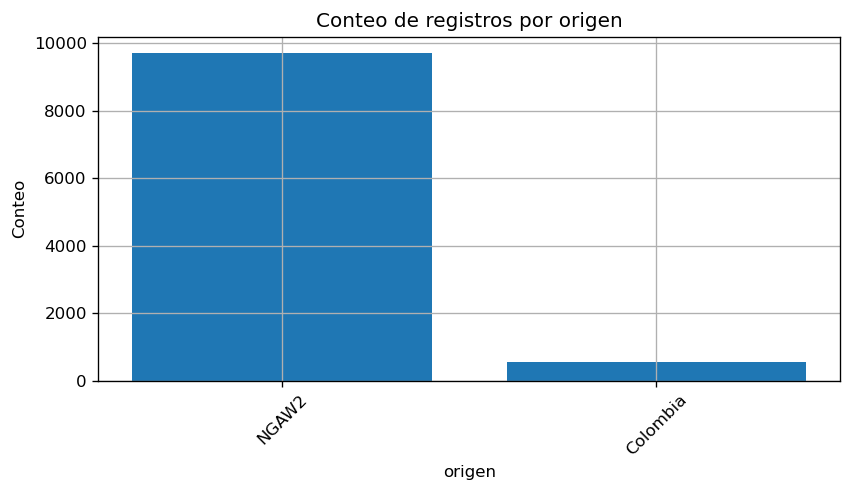

In [40]:

counts = df['origen'].astype('string').value_counts()

plt.figure(figsize=(7.2, 4.2), dpi=120)
plt.bar(counts.index, counts.values)
plt.title("Conteo de registros por origen")
plt.xlabel("origen")
plt.ylabel("Conteo")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

NGAW2 domina el dataset, y Colombia es minoría. Implicará que las métricas reflejarían principalmente NGAW2 si no se hace un buen ajuste.

### Pruebas de hipótesis de normalidad

In [41]:
num_cols = [
    "Hypocenter Depth (km)", "Magnitude", "Rrup_OpenQuake", "Tmax",
    "Seismic Latitude", "Seismic Longitude",
    "Station Latitude", "Station Longitude",
    "T_0.01_RotD50"
]


In [42]:
from scipy.stats import kstest

rows = []

for col in num_cols:
    s = pd.to_numeric(df[col], errors="coerce").dropna()
    n = len(s)

    if n < 3:
        rows.append({"variable": col, "n": n, "D": np.nan, "p_value": np.nan})
        continue
    n_used = n


    mu = float(s.mean())
    sigma = float(s.std(ddof=1))

    if sigma == 0:
        rows.append({"variable": col, "n": n, "n_used": n_used, "D": np.nan, "p_value": np.nan})
        continue

    z = (s - mu) / sigma
    D, p = kstest(z.values, "norm")  

    rows.append({
        "variable": col,
        "n_used": n_used,
        "mu": mu,
        "sigma": sigma,
        "D": float(D),
        "p_value": float(p)
    })

ks_df = pd.DataFrame(rows).sort_values("p_value", ascending=True)
print(ks_df)

                variable  n_used         mu       sigma         D  \
7      Station Longitude   10239   1.236687  120.297085  0.281791   
6       Station Latitude   10239  30.661651   13.862467  0.258112   
5      Seismic Longitude   10239   1.283627  120.050236  0.283092   
4       Seismic Latitude   10239  30.674930   13.952354  0.245196   
3                   Tmax   10204  13.212392   12.731730  0.160194   
0  Hypocenter Depth (km)   10239  10.611286    5.111330  0.144010   
1              Magnitude   10239   5.912488    1.139730  0.127684   
2         Rrup_OpenQuake   10239   4.206842    1.026970  0.041518   
8          T_0.01_RotD50   10239  -4.115497    1.698535  0.020279   

         p_value  
7   0.000000e+00  
6   0.000000e+00  
5   0.000000e+00  
4   0.000000e+00  
3  3.143910e-229  
0  9.172062e-186  
1  5.555801e-146  
2   8.985136e-16  
8   4.340063e-04  


Como todos los p valores están por debajo del 5%, se rechaza la hipótesis nula de que las variables tienen un comportamiento con distribución normal.